##**Data 201 --- Week 5 Assignment**

####**Resampling Methods with the Iris Dataset**

Iris Wu

###**Load the Dataset**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


###**Tasks**

In [2]:
#print the number of observations in the dataset
print(len(iris))

150


In [3]:
#print the column names
print(iris.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [4]:
#count how many observations exist for each species
print(iris["species"].value_counts)

<bound method IndexOpsMixin.value_counts of 0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object>


###**Part 1 --- Bootstrap Resampling**

####**Task 1 --- Basic Statistics**

In [5]:
#compute the mean for sepal length
print(np.mean(iris["sepal_length"]))

5.843333333333334


In [6]:
#compute the median for sepal length
print(np.median(iris["sepal_length"]))

5.8


In [7]:
#compute the standard deviation for sepal length
print(np.std(iris["sepal_length"]))

0.8253012917851409


Text(0, 0.5, 'Frequency')

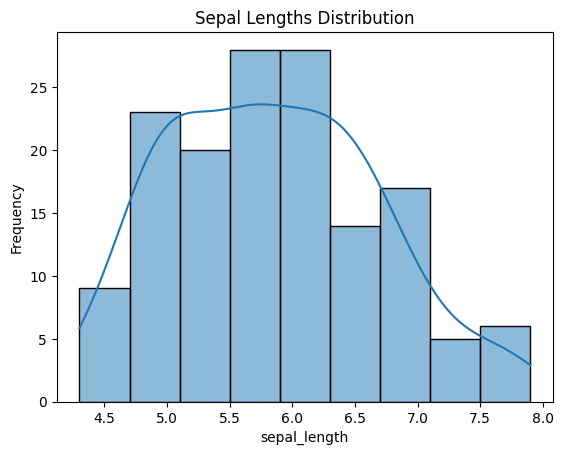

In [8]:
#plot the sepal lengths
sns.histplot(iris["sepal_length"], kde = True)
plt.title("Sepal Lengths Distribution")
plt.ylabel("Frequency")

####**Task 2 --- Bootstrap the Mean**

Bootstrapped Mean: 5.85
Bootstrapped Std: 0.0727


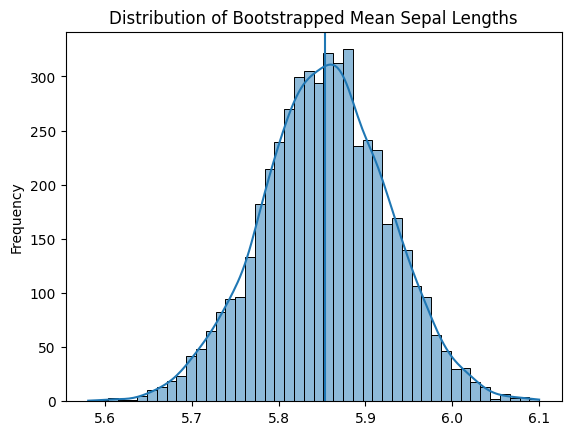

In [9]:
sample_n = 150
sample = np.random.choice(iris["sepal_length"], size=sample_n, replace=True)
n_bootstrap = 5000

bootstrap_means = []
for b in range(n_bootstrap):
    bootstrap_means.append(np.mean(np.random.choice(sample, size=sample_n, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Mean Sepal Lengths')
plt.ylabel('Frequency')

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'Bootstrapped Std: {np.std(bootstrap_means):.3}')

####**Task 3 --- Confidence Interval**



In [10]:
#compute the 95% confidence interval using the percentile method: CI = [2.5%, 97.5%]
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)
print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')




Bootstrapped Mean: 5.85
95% Confidence Intervals: [5.71, 6.0]


The bootstrapped mean is 5.78, the lower bound is 5.66, and the upper bound is 5.91. The narrow interval indicates that 150 observations is sufficient to estimate mean sepal length reliably.

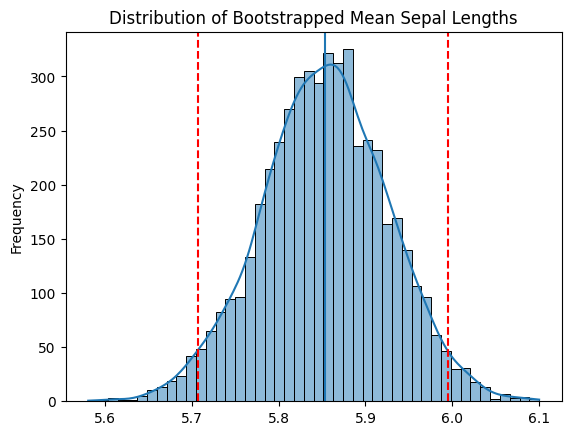

In [11]:
#plot the lower and upper bounds
sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Mean Sepal Lengths')
plt.ylabel('Frequency')
plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')


Bootstrapping requires replacement because it creates a sample of independent random samples that vary from each other. This variation  allows us to estimate the uncertainity of a statistic. Without replacement, the value drawn from one sample affects the possibility of values from the next sample, so the samples are not independent. Each sample contains an observation from the dataset exactly once. As a result, the resampled mean would be identical to the original mean, which defeats the purpose of estimating the mean of the broader population.

###**Part 2 --- Jackknife Resampling**




####**Task 4 --- Jackknife the Mean**

In [17]:

def jackknife_resampling(sample):
    n = sample_n
    jackknife_means = np.zeros(n)

    # Leave-one-out resampling
    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    # Jackknife estimator (mean of the means)
    jackknife_mean = np.mean(jackknife_means)

    # Bias estimation
    original_mean = np.mean(sample)
    bias = (n - 1)*(original_mean - jackknife_mean)
    #print(f'Bias: {bias}')

    # Variance estimation
    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(sample)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Jackknife Mean: 5.852666666666666
Bias: 0.0
Variance: 0.005356328113348232


Jackknife Mean: 5.85
Jackknife Std: 0.006


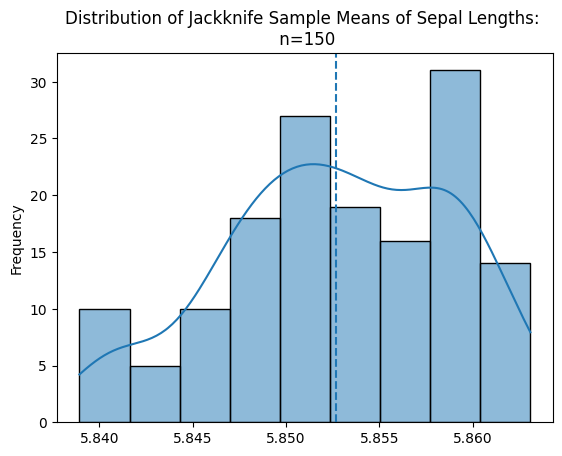

In [18]:
#plot the distribution of jackknife means
sns.histplot(jackknife_means, kde=True)
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(f'Distribution of Jackknife Sample Means of Sepal Lengths: \n n={sample_n}')
plt.ylabel('Frequency')

print(f'Jackknife Mean: {np.mean(jackknife_means):.3}')
print(f'Jackknife Std: {np.std(jackknife_means):.3}')

If the dataset contains n observations then n samples of size n-1 are created. For the sepal lengths dataset in this assignment, 150 samples of 149 observations each are created.

###**Part 3 --- Permutation Test**

####**Task 5 --- Observed Statistic**

In [26]:
#compute the observed difference in mean sepal lengths between versicolor and virginica
mean_diff = np.mean(iris[iris["species"] == "versicolor"]["sepal_length"]) - np.mean(iris[iris["species"] == "virginica"]["sepal_length"])
print(mean_diff)

-0.6519999999999984


####**Task 6 --- Permutation Simulation**

In [29]:
#combine the two species into one dataset
both_species = np.concatenate([iris[iris["species"] == "versicolor"]["sepal_length"], iris[iris["species"] == "virginica"]["sepal_length"]])

In [49]:
#Define the array for the simulated differences
simu_diff = []
n_samples = 5000
n_versicolor = len(iris[iris["species"] == "versicolor"]["sepal_length"])


In [50]:
#run the permutation test
for i in range(n_samples):
  perm_sample = np.random.permutation(both_species)
  perm_treatment = perm_sample[:n_versicolor]
  perm_control = perm_sample[n_versicolor:]
  perm_diff = np.mean(perm_treatment) - np.mean(perm_control)
  simu_diff.append(perm_diff)

In [51]:
#calculate the 95% confidence interval
upper = np.quantile(simu_diff, 0.975)
lower = np.quantile(simu_diff, 0.025)
print(lower, upper)

-0.259999999999998 0.26010000000000005


In [56]:
print(f'Permutated Mean Difference: {np.mean(simu_diff):.3}')
print(f'Actual Difference of Means: {mean_diff:.3}')

Permutated Mean Difference: 0.000539
Actual Difference of Means: -0.652


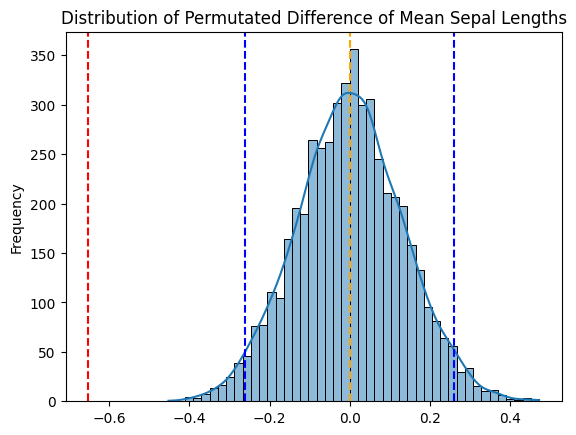

In [52]:
#plot the distribution of permutated differences of means
sns.histplot(simu_diff, kde=True)
plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color='orange', linestyle='--')
plt.axvline(x=mean_diff, ymin=0, ymax=1, color='red', linestyle='--')
plt.title('Distribution of Permutated Difference of Mean Sepal Lengths')
plt.ylabel('Frequency')

plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')



####**Task 7 --- Calculate the p-value**

In [54]:
p_value = np.sum(np.abs(simu_diff)>= np.abs(mean_diff))/5000
print(p_value)

0.0


The p-value is less than 0.05, so there is sufficient evidence to reject the null hypothesis.

####**Interpretation**

The null hypothesis is that no difference exists between the sepal lengths of the two iris species, versicolor and virginica. The permutation distribution represents the full range of differences produced by 5000 random shuffles of the dataset. Since the p-value is less than 0.05 and the observed mean falls outside the 95% confidence interval, there is enough evidence to reject the null hypothesis. The sepal lengths between versicolor and virginica are significantly different.
